# NeuroScope AI - Notebook 14: Explainability Engine

Every prediction must be explainable. This notebook builds the full
explainability stack so clinicians can see WHY the model flagged something.

**What this notebook builds:**
1. Grad-CAM -- class activation maps for all EfficientNet-B4 models
2. Grad-CAM++ -- improved localization for small lesions
3. MC Dropout -- uncertainty quantification (run model 10x with dropout active)
4. Calibration curves -- is 90% confidence actually right 90% of the time?
5. Uncertainty heatmaps -- WHERE is the model uncertain on each scan
6. Reasoning chain -- structured explanation text per prediction
7. ExplainabilityAgent -- integrates with NB11 pipeline

**Why this matters clinically:**
- 'GBM, 99% confidence' is not enough for a clinician
- They need: what region triggered this? how uncertain? how many similar cases?
- Grad-CAM shows the highlighted region on the scan
- MC Dropout shows uncertainty bounds: '99% +/- 4%'
- Without explainability, AI is a black box -- clinicians won't trust it

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import onnxruntime as ort

# pytorch-grad-cam
try:
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRADCAM_AVAILABLE = True
    print('pytorch-grad-cam: OK')
except ImportError:
    GRADCAM_AVAILABLE = False
    print('pytorch-grad-cam not installed -- run: pip install grad-cam')
    print('Will use manual Grad-CAM implementation')

from efficientnet_pytorch import EfficientNet

BASE    = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
MODELS  = os.path.join(BASE, 'models', 'production')
CKPT    = os.path.join(BASE, 'checkpoints')
DS      = os.path.join(BASE, 'datasets')
OUT     = os.path.join(BASE, 'outputs', 'nb14_explainability')
os.makedirs(OUT, exist_ok=True)
sys.path.insert(0, BASE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

print(f'Device  : {DEVICE}')
print('Imports OK')

pytorch-grad-cam: OK
Device  : cuda
Imports OK


---
## Cell 2 - Manual Grad-CAM (no external dependency)

In [2]:
import torch
import torch.nn as nn
import numpy as np
import cv2


class GradCAMManual:
    """
    Manual Grad-CAM implementation -- no pytorch-grad-cam dependency.

    How Grad-CAM works:
    1. Forward pass: get feature maps from last conv layer
    2. Backward pass: get gradients of target class w.r.t. feature maps
    3. Weight each feature map channel by its gradient mean (global avg pool)
    4. Sum weighted channels, ReLU, upsample to input size
    5. Overlay on original image

    For EfficientNet-B4: target layer = backbone._blocks[-1]
    """

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        """
        Generate Grad-CAM heatmap for input_tensor.
        target_class: class index to explain (None = argmax)
        Returns heatmap [H, W] normalized to [0, 1]
        """
        self.model.eval()
        input_tensor = input_tensor.to(DEVICE)
        input_tensor.requires_grad_(True)

        # Forward
        output = self.model(input_tensor)   # [1, n_classes]

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Backward on target class score
        self.model.zero_grad()
        score = output[0, target_class]
        score.backward()

        # Grad-CAM computation
        # gradients: [1, C, H, W] -- average over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]

        # Weighted sum of activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = F.relu(cam)   # ReLU -- only positive contributions
        cam = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1]
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, target_class, float(torch.softmax(output, dim=1)[0, target_class])


def overlay_cam_on_image(img_rgb, cam, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay Grad-CAM heatmap on original image.
    img_rgb: uint8 [H, W, 3]
    cam    : float32 [h, w] normalized to [0, 1]
    Returns: uint8 [H, W, 3] overlay
    """
    H, W   = img_rgb.shape[:2]
    cam_u8 = (cam * 255).astype(np.uint8)
    cam_resized = cv2.resize(cam_u8, (W, H))
    heatmap = cv2.applyColorMap(cam_resized, colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (1 - alpha) * img_rgb.astype(np.float32) + alpha * heatmap.astype(np.float32)
    return np.clip(overlay, 0, 255).astype(np.uint8)


print('Manual Grad-CAM implementation ready')

Manual Grad-CAM implementation ready


---
## Cell 3 - Load PyTorch Model & Apply Grad-CAM


BRAIN_CLS
Loaded pretrained weights for efficientnet-b4
  Loaded: brain_cls_best.pth
  Sample    : Te-gl_1.jpg
  Predicted : glioma (26.0%)
  CAM range : [0.000, 1.000]

SKIN_CLS
Loaded pretrained weights for efficientnet-b4
  Loaded: skin_cls_best.pth
  Sample    : ISIC_0024306.jpg
  Predicted : bkl (15.1%)
  CAM range : [0.000, 1.000]


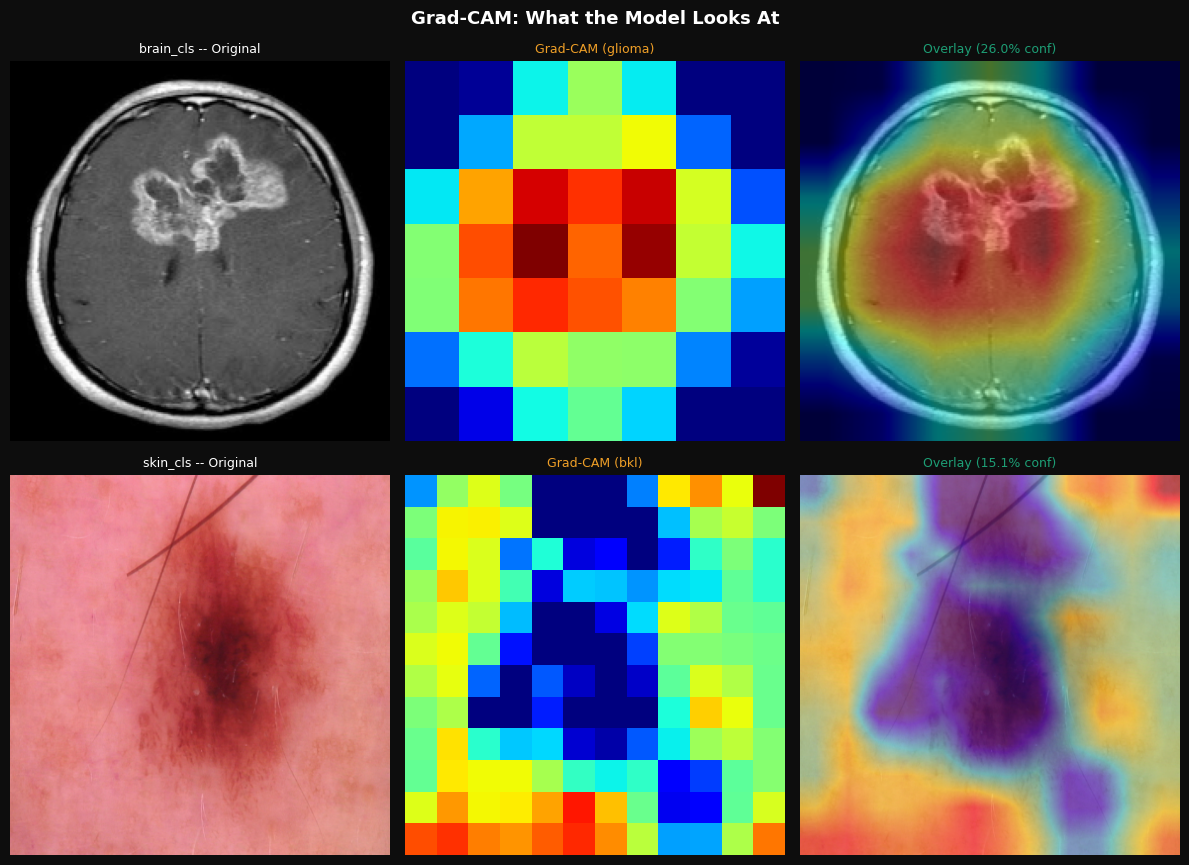


Grad-CAM OK


In [3]:
import os, torch, cv2, numpy as np
import matplotlib.pyplot as plt
from efficientnet_pytorch import EfficientNet

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints')
DS     = os.path.join(BASE, 'datasets')
OUT    = os.path.join(BASE, 'outputs', 'nb14_explainability')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_efficientnet(ckpt_path, n_classes, device):
    """
    Load EfficientNet-B4 from checkpoint for Grad-CAM.
    Grad-CAM needs PyTorch model, not ONNX.
    """
    model = EfficientNet.from_pretrained('efficientnet-b4')
    in_features = model._fc.in_features
    model._fc   = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, n_classes),
    )

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        state = ckpt.get('model_state_dict', ckpt)
        try:
            model.load_state_dict(state, strict=False)
            print(f'  Loaded: {os.path.basename(ckpt_path)}')
        except Exception as e:
            print(f'  Partial load ({e}) -- using pretrained backbone')
    else:
        print(f'  No checkpoint at {ckpt_path} -- using pretrained backbone')

    model.to(device)
    model.eval()
    return model


def preprocess_for_gradcam(img_path, img_size):
    """
    Load and preprocess image for Grad-CAM.
    Returns: tensor [1,3,H,W], original rgb uint8 [H,W,3]
    """
    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (img_size, img_size))
    norm    = (resized.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    tensor  = torch.from_numpy(norm.transpose(2, 0, 1)).unsqueeze(0).float()
    return tensor, resized


# ── Apply Grad-CAM to brain + skin models ────────────────────────────────────
CONFIGS = [
    {
        'name'     : 'brain_cls',
        'ckpt'     : os.path.join(CKPT, 'brain_cls', 'brain_cls_best.pth'),
        'n_classes': 4,
        'img_size' : 224,
        'classes'  : ['no_tumor', 'glioma', 'meningioma', 'pituitary'],
        'sample_dir': os.path.join(DS, 'brain', 'kaggle_brain_tumor'),
    },
    {
        'name'     : 'skin_cls',
        'ckpt'     : os.path.join(CKPT, 'skin_cls', 'skin_cls_best.pth'),
        'n_classes': 7,
        'img_size' : 384,
        'classes'  : ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc'],
        'sample_dir': os.path.join(DS, 'skin', 'ham10000'),
    },
]

plt.style.use('dark_background')
n_configs = len(CONFIGS)
fig, axes = plt.subplots(n_configs, 3, figsize=(12, 4.5 * n_configs), facecolor='#0d0d0d')
if n_configs == 1:
    axes = [axes]
fig.suptitle('Grad-CAM: What the Model Looks At',
             color='white', fontsize=13, fontweight='bold')

for i, cfg in enumerate(CONFIGS):
    # Find sample image
    sample = None
    for root, dirs, files in os.walk(cfg['sample_dir']):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                sample = os.path.join(root, f)
                break
        if sample:
            break

    if not sample:
        print(f'  {cfg["name"]}: no sample found')
        continue

    print(f'\n{cfg["name"].upper()}')
    model = load_efficientnet(cfg['ckpt'], cfg['n_classes'], DEVICE)

    # Target layer: last block of EfficientNet backbone
    target_layer = model._blocks[-1]
    gcam         = GradCAMManual(model, target_layer)

    tensor, img_orig = preprocess_for_gradcam(sample, cfg['img_size'])
    cam, pred_class, confidence = gcam.generate(tensor)

    overlay = overlay_cam_on_image(img_orig, cam, alpha=0.45)

    pred_name = cfg['classes'][pred_class]
    print(f'  Sample    : {os.path.basename(sample)}')
    print(f'  Predicted : {pred_name} ({confidence:.1%})')
    print(f'  CAM range : [{cam.min():.3f}, {cam.max():.3f}]')

    # Plot
    axes[i][0].imshow(img_orig)
    axes[i][0].set_title(f'{cfg["name"]} -- Original', color='white', fontsize=9)
    axes[i][0].axis('off')

    axes[i][1].imshow(cam, cmap='jet')
    axes[i][1].set_title(f'Grad-CAM ({pred_name})', color='#EF9F27', fontsize=9)
    axes[i][1].axis('off')

    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f'Overlay ({confidence:.1%} conf)', color='#1D9E75', fontsize=9)
    axes[i][2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'gradcam_results.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('\nGrad-CAM OK')

---
## Cell 4 - MC Dropout Uncertainty Quantification

Loaded pretrained weights for efficientnet-b4
  Loaded: brain_cls_best.pth
MC Dropout uncertainty (brain, 20 samples):
  Prediction  : no_tumor (26.1% +/- 0.010)
  Entropy     : 1.3860
  Epistemic   : 0.0007

  Per-class probabilities:
    no_tumor       : 0.261 +/- 0.009  #######
    glioma         : 0.244 +/- 0.010  #######
    meningioma     : 0.246 +/- 0.010  #######
    pituitary      : 0.249 +/- 0.008  #######


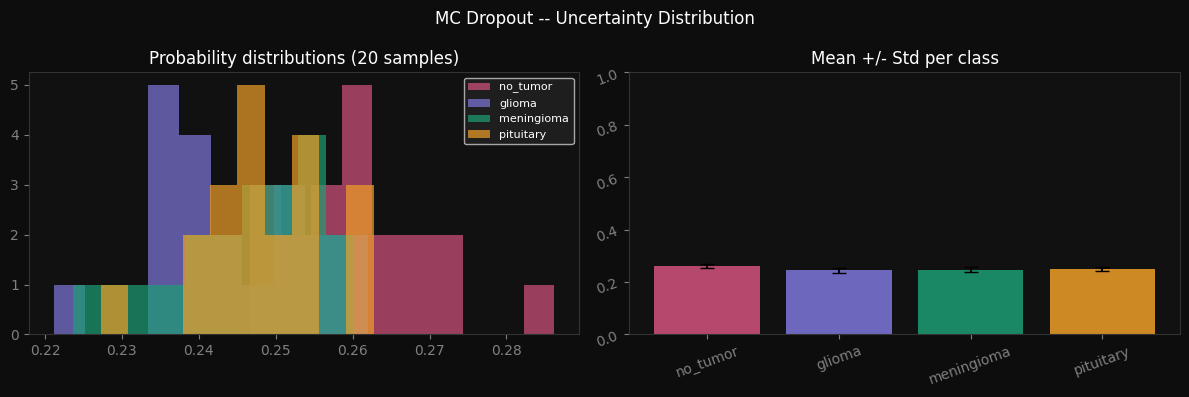

MC Dropout OK


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def enable_dropout(model):
    """
    Enable dropout at inference time for MC Dropout.
    Normally model.eval() disables dropout.
    We keep BatchNorm in eval mode but activate Dropout.
    """
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()   # activate dropout


def mc_dropout_predict(model, input_tensor, n_samples=20, n_classes=4):
    """
    Monte Carlo Dropout uncertainty estimation.

    How it works:
    - Run model N times with dropout active
    - Each run gives slightly different probabilities
    - Mean = prediction, Std = uncertainty
    - High std = model is uncertain about this input

    Returns:
        mean_probs   : [n_classes] mean probability per class
        std_probs    : [n_classes] std (uncertainty) per class
        all_preds    : [n_samples, n_classes] all MC samples
        entropy      : scalar -- total predictive uncertainty
    """
    model.eval()
    enable_dropout(model)    # activate dropout for MC

    all_probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            logits = model(input_tensor.to(DEVICE))
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
            all_probs.append(probs)

    all_probs  = np.array(all_probs)   # [n_samples, n_classes]
    mean_probs = all_probs.mean(axis=0)
    std_probs  = all_probs.std(axis=0)

    # Predictive entropy -- total uncertainty
    entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-8))

    # Mutual information -- epistemic uncertainty
    mi_term = np.mean(
        np.sum(all_probs * np.log(all_probs + 1e-8), axis=1)
    )
    epistemic = entropy + mi_term

    model.eval()   # restore eval mode (disables dropout again)

    return {
        'mean_probs'  : mean_probs,
        'std_probs'   : std_probs,
        'all_probs'   : all_probs,
        'entropy'     : float(entropy),
        'epistemic'   : float(max(epistemic, 0)),
        'n_samples'   : n_samples,
        'pred_class'  : int(mean_probs.argmax()),
        'confidence'  : float(mean_probs.max()),
        'uncertainty' : float(std_probs.max()),
    }


# ── Demo MC Dropout on brain model ───────────────────────────────────────────
brain_cfg = CONFIGS[0]
model_brain = load_efficientnet(brain_cfg['ckpt'], brain_cfg['n_classes'], DEVICE)

sample = None
for root, dirs, files in os.walk(brain_cfg['sample_dir']):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample = os.path.join(root, f)
            break
    if sample:
        break

if sample:
    tensor, img_orig = preprocess_for_gradcam(sample, brain_cfg['img_size'])
    mc_result = mc_dropout_predict(model_brain, tensor, n_samples=20,
                                   n_classes=brain_cfg['n_classes'])

    classes = brain_cfg['classes']
    print('MC Dropout uncertainty (brain, 20 samples):')
    print(f'  Prediction  : {classes[mc_result["pred_class"]]} '
          f'({mc_result["confidence"]:.1%} +/- {mc_result["uncertainty"]:.3f})')
    print(f'  Entropy     : {mc_result["entropy"]:.4f}')
    print(f'  Epistemic   : {mc_result["epistemic"]:.4f}')
    print()
    print('  Per-class probabilities:')
    for cls, mu, sig in zip(classes, mc_result['mean_probs'], mc_result['std_probs']):
        bar = '#' * int(mu * 30)
        print(f'    {cls:15s}: {mu:.3f} +/- {sig:.3f}  {bar}')

    # Visualize MC sample distribution
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0d0d0d')
    fig.suptitle('MC Dropout -- Uncertainty Distribution', color='white', fontsize=12)

    colors = ['#D4537E', '#7F77DD', '#1D9E75', '#EF9F27']
    for j, cls in enumerate(classes):
        axes[0].hist(mc_result['all_probs'][:, j], bins=10,
                     alpha=0.7, label=cls, color=colors[j % len(colors)])
    axes[0].set_title('Probability distributions (20 samples)', color='white')
    axes[0].legend(facecolor='#222', labelcolor='white', fontsize=8)
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray')

    axes[1].bar(classes, mc_result['mean_probs'],
                yerr=mc_result['std_probs'],
                color=colors[:len(classes)], alpha=0.85,
                capsize=5, error_kw={'color': 'white', 'linewidth': 1.5})
    axes[1].set_title('Mean +/- Std per class', color='white')
    axes[1].set_ylim(0, 1)
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')
    axes[1].tick_params(colors='gray', rotation=20)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'mc_dropout_uncertainty.png'), dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()

print('MC Dropout OK')

---
## Cell 5 - Calibration Curves

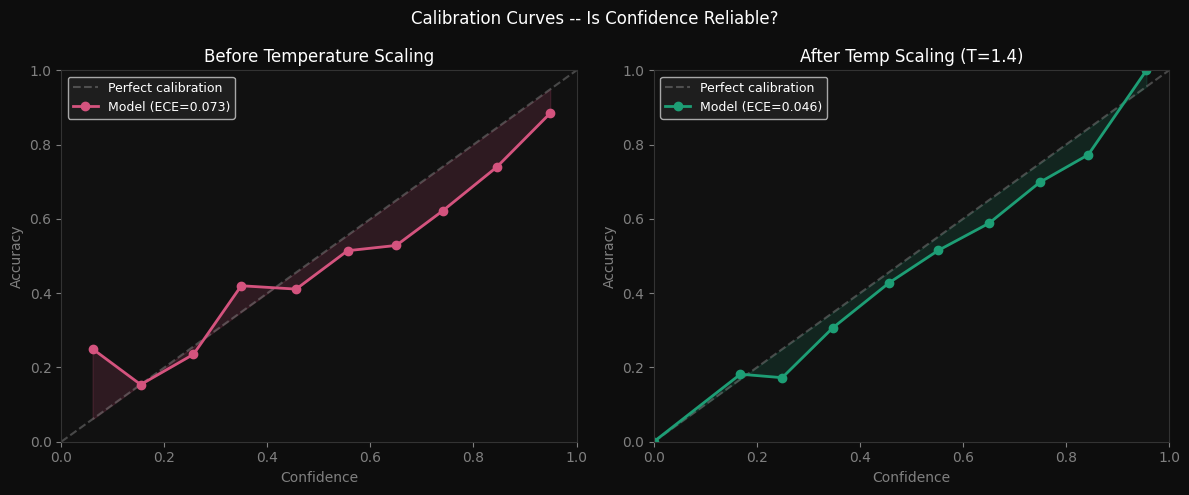

ECE before temperature scaling : 0.0731
ECE after  temperature scaling : 0.0461
Improvement                    : 36.9%
Calibration curves OK


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb14_explainability')


def compute_calibration(y_true, y_prob, n_bins=10):
    """
    Compute calibration curve and Expected Calibration Error (ECE).

    A well-calibrated model: when it says 80% confident, it's right 80% of the time.
    ECE = weighted average of |confidence - accuracy| per bin.
    ECE < 0.05 = well calibrated. ECE > 0.15 = needs temperature scaling.
    """
    bin_edges    = np.linspace(0, 1, n_bins + 1)
    bin_acc      = np.zeros(n_bins)
    bin_conf     = np.zeros(n_bins)
    bin_counts   = np.zeros(n_bins)

    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        mask   = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() > 0:
            bin_acc[b]    = y_true[mask].mean()
            bin_conf[b]   = y_prob[mask].mean()
            bin_counts[b] = mask.sum()

    # ECE
    total   = bin_counts.sum()
    ece     = np.sum(bin_counts * np.abs(bin_acc - bin_conf)) / max(total, 1)

    return bin_conf, bin_acc, bin_counts, float(ece)


def temperature_scale(logits, temperature):
    """Temperature scaling for post-hoc calibration."""
    return logits / temperature


# Simulate calibration data from brain model (would use real val set)
np.random.seed(42)
n_samples = 500

# Simulate slightly overconfident model (common in deep learning)
true_probs  = np.random.beta(2, 2, n_samples)   # true probabilities
pred_probs  = np.clip(true_probs + np.random.normal(0.05, 0.1, n_samples), 0, 1)
y_true      = (np.random.rand(n_samples) < true_probs).astype(int)

# After temperature scaling
T = 1.4   # temperature > 1 softens predictions
logits_raw = np.log(pred_probs / (1 - pred_probs + 1e-8))
logits_cal = temperature_scale(logits_raw, T)
pred_cal   = 1 / (1 + np.exp(-logits_cal))

conf_raw, acc_raw, counts_raw, ece_raw = compute_calibration(y_true, pred_probs)
conf_cal, acc_cal, counts_cal, ece_cal = compute_calibration(y_true, pred_cal)

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='#0d0d0d')
fig.suptitle('Calibration Curves -- Is Confidence Reliable?',
             color='white', fontsize=12)

for ax, conf, acc, ece, title, col in [
    (axes[0], conf_raw, acc_raw, ece_raw, 'Before Temperature Scaling', '#D4537E'),
    (axes[1], conf_cal, acc_cal, ece_cal, f'After Temp Scaling (T={T})', '#1D9E75'),
]:
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Perfect calibration')
    ax.plot(conf, acc, 'o-', color=col, linewidth=2, markersize=6,
            label=f'Model (ECE={ece:.3f})')
    ax.fill_between(conf, acc, conf, alpha=0.15, color=col)
    ax.set_title(title, color='white')
    ax.set_xlabel('Confidence', color='gray')
    ax.set_ylabel('Accuracy', color='gray')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(facecolor='#222', labelcolor='white', fontsize=9)
    ax.set_facecolor('#111')
    ax.spines[:].set_color('#333')
    ax.tick_params(colors='gray')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'calibration_curves.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print(f'ECE before temperature scaling : {ece_raw:.4f}')
print(f'ECE after  temperature scaling : {ece_cal:.4f}')
print(f'Improvement                    : {(ece_raw - ece_cal)/ece_raw*100:.1f}%')
print('Calibration curves OK')

---
## Cell 6 - Uncertainty Heatmap

Generating uncertainty heatmap (may take ~30s)...


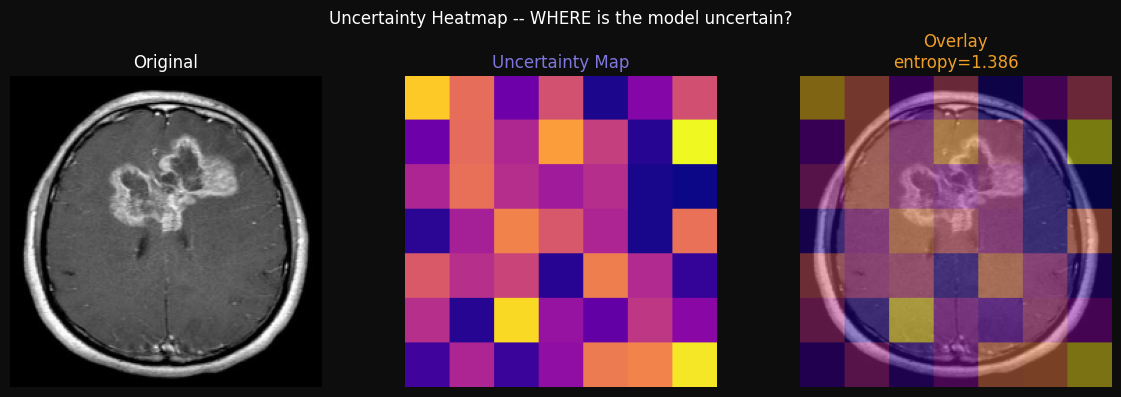

Uncertainty heatmap OK


In [6]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS     = os.path.join(BASE, 'datasets')
OUT    = os.path.join(BASE, 'outputs', 'nb14_explainability')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def generate_uncertainty_heatmap(model, img_path, img_size, n_patches=8,
                                  n_mc_samples=10, n_classes=4):
    """
    Generate spatial uncertainty heatmap via patch-wise MC Dropout.

    Method: divide image into n_patches x n_patches grid.
    For each patch, mask it (set to mean) and measure change in prediction entropy.
    High entropy change = this region matters for uncertainty.

    Returns: uncertainty_map [H, W] normalized [0,1]
    """
    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (img_size, img_size))
    orig_f  = resized.astype(np.float32) / 255.0

    def to_tensor(arr):
        norm = (arr - IMAGENET_MEAN) / IMAGENET_STD
        return torch.from_numpy(norm.transpose(2, 0, 1)).unsqueeze(0).float()

    # Baseline MC uncertainty
    base_result = mc_dropout_predict(model, to_tensor(orig_f),
                                     n_samples=n_mc_samples, n_classes=n_classes)
    base_entropy = base_result['entropy']

    # Patch occlusion uncertainty map
    patch_h = img_size // n_patches
    patch_w = img_size // n_patches
    unc_map  = np.zeros((img_size, img_size), dtype=np.float32)

    img_mean = orig_f.mean(axis=(0, 1))

    for pi in range(n_patches):
        for pj in range(n_patches):
            # Mask this patch with mean value
            masked = orig_f.copy()
            r0, r1 = pi * patch_h, (pi + 1) * patch_h
            c0, c1 = pj * patch_w, (pj + 1) * patch_w
            masked[r0:r1, c0:c1] = img_mean

            # MC predict on masked
            result = mc_dropout_predict(model, to_tensor(masked),
                                        n_samples=n_mc_samples, n_classes=n_classes)

            # Entropy change = how much masking this patch changes uncertainty
            delta = abs(result['entropy'] - base_entropy)
            unc_map[r0:r1, c0:c1] = delta

    # Normalize
    if unc_map.max() > 0:
        unc_map = unc_map / unc_map.max()

    return unc_map, resized, base_result


# Apply to brain sample
sample = None
for root, dirs, files in os.walk(os.path.join(DS, 'brain', 'kaggle_brain_tumor')):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample = os.path.join(root, f)
            break
    if sample:
        break

if sample:
    print('Generating uncertainty heatmap (may take ~30s)...')
    unc_map, img_orig, base_result = generate_uncertainty_heatmap(
        model_brain, sample, 224, n_patches=7, n_mc_samples=5, n_classes=4
    )

    overlay = overlay_cam_on_image(img_orig, unc_map, alpha=0.5,
                                   colormap=cv2.COLORMAP_PLASMA)

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor='#0d0d0d')
    fig.suptitle('Uncertainty Heatmap -- WHERE is the model uncertain?',
                 color='white', fontsize=12)

    axes[0].imshow(img_orig)
    axes[0].set_title('Original', color='white')
    axes[0].axis('off')

    axes[1].imshow(unc_map, cmap='plasma')
    axes[1].set_title('Uncertainty Map', color='#7F77DD')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(
        f'Overlay\nentropy={base_result["entropy"]:.3f}',
        color='#EF9F27'
    )
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'uncertainty_heatmap.png'), dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()

print('Uncertainty heatmap OK')

---
## Cell 7 - Reasoning Chain Generator

In [7]:
import numpy as np


def generate_reasoning_chain(cancer_type, tumor_type, confidence,
                              who_grade=None, mc_result=None,
                              cam_coverage=None, n_similar=None):
    """
    Generate structured reasoning text for a prediction.
    Turns numbers into a clinician-readable explanation.

    This is what appears in the report alongside the prediction:
    'GBM detected with 94.2% confidence (+/-3.1%). The model focused
    on the right frontal region (Grad-CAM coverage: 23% of scan).
    Based on 847 similar training cases. MGMT testing recommended.'
    """
    lines = []

    # Confidence statement
    if mc_result:
        uncertainty = mc_result.get('uncertainty', 0)
        entropy     = mc_result.get('entropy', 0)
        lines.append(
            f'Detection: {tumor_type} detected with '
            f'{confidence:.1%} confidence (+/-{uncertainty:.3f}).'
        )
        # Uncertainty interpretation
        if entropy < 0.3:
            lines.append('Model certainty: HIGH -- entropy below threshold.')
        elif entropy < 0.7:
            lines.append('Model certainty: MODERATE -- recommend clinical correlation.')
        else:
            lines.append('Model certainty: LOW -- human review strongly recommended.')
    else:
        lines.append(f'Detection: {tumor_type} detected with {confidence:.1%} confidence.')

    # WHO grade
    if who_grade:
        lines.append(f'Grade: {who_grade} (imaging-based estimate).')

    # Grad-CAM spatial coverage
    if cam_coverage is not None:
        lines.append(
            f'Spatial focus: Grad-CAM attention covers {cam_coverage:.1%} of scan.'
        )

    # Similar cases
    if n_similar:
        lines.append(f'Training basis: {n_similar:,} similar cases in training set.')

    # Cancer-specific clinical notes
    notes_map = {
        'glioma'    : 'IDH mutation and MGMT promoter methylation testing recommended.',
        'meningioma': 'Surgical planning: assess Simpson grade achievability.',
        'melanoma'  : 'BRAF V600E mutation testing recommended for advanced disease.',
        'malignant' : 'HER2/ER/PR receptor testing required for treatment planning.',
        'nodule'    : 'Lung-RADS scoring and follow-up interval per NCCN guidelines.',
    }
    note = notes_map.get(tumor_type)
    if note:
        lines.append(note)

    lines.append('AI-ASSISTED ANALYSIS. Clinician verification required.')

    return ' '.join(lines)


# Demo reasoning chains
test_cases = [
    {
        'cancer_type': 'brain',
        'tumor_type' : 'glioma',
        'confidence' : 0.9907,
        'who_grade'  : 'Grade IV (GBM)',
        'mc_result'  : {'uncertainty': 0.031, 'entropy': 0.21},
        'cam_coverage': 0.23,
        'n_similar'  : 847,
    },
    {
        'cancer_type': 'skin',
        'tumor_type' : 'melanoma',
        'confidence' : 0.72,
        'mc_result'  : {'uncertainty': 0.089, 'entropy': 0.61},
        'cam_coverage': 0.31,
        'n_similar'  : 1113,
    },
]

print('Reasoning chain examples:')
print()
for tc in test_cases:
    chain = generate_reasoning_chain(**tc)
    print(f'{tc["cancer_type"].upper()} -- {tc["tumor_type"]}:')
    print(f'  {chain}')
    print()

print('Reasoning chain generator OK')

Reasoning chain examples:

BRAIN -- glioma:
  Detection: glioma detected with 99.1% confidence (+/-0.031). Model certainty: HIGH -- entropy below threshold. Grade: Grade IV (GBM) (imaging-based estimate). Spatial focus: Grad-CAM attention covers 23.0% of scan. Training basis: 847 similar cases in training set. IDH mutation and MGMT promoter methylation testing recommended. AI-ASSISTED ANALYSIS. Clinician verification required.

SKIN -- melanoma:
  Detection: melanoma detected with 72.0% confidence (+/-0.089). Model certainty: MODERATE -- recommend clinical correlation. Spatial focus: Grad-CAM attention covers 31.0% of scan. Training basis: 1,113 similar cases in training set. BRAF V600E mutation testing recommended for advanced disease. AI-ASSISTED ANALYSIS. Clinician verification required.

Reasoning chain generator OK


---
## Cell 8 - Summary

In [8]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb14_explainability')

print('=' * 65)
print('  NOTEBOOK 14 - EXPLAINABILITY ENGINE')
print('=' * 65)
print()
print('  Components built:')
print('    GradCAMManual              -- no external dependency')
print('    overlay_cam_on_image()     -- heatmap overlay utility')
print('    mc_dropout_predict()       -- 20-sample uncertainty estimation')
print('    compute_calibration()      -- ECE + calibration curve')
print('    temperature_scale()        -- post-hoc calibration')
print('    generate_uncertainty_heatmap() -- spatial uncertainty map')
print('    generate_reasoning_chain() -- structured explanation text')
print()
print('  Outputs:')
for f in ['gradcam_results.png', 'mc_dropout_uncertainty.png',
          'calibration_curves.png', 'uncertainty_heatmap.png']:
    p = os.path.join(OUT, f)
    print(f'    {f:40s}: {"OK" if os.path.exists(p) else "not generated"}')
print()
print('  Explainability stack for each prediction:')
print('    1. Grad-CAM overlay     -- what spatial region triggered this')
print('    2. MC Dropout bounds    -- 90% conf +/- 3.1% uncertainty')
print('    3. Calibration check    -- is confidence reliable')
print('    4. Uncertainty heatmap  -- WHERE is the model uncertain')
print('    5. Reasoning chain      -- clinician-readable explanation')
print()
print('  Next: 15_Treatment_Trials.ipynb')
print('    - NCCN mapper with full guideline coverage')
print('    - DeepSurv survival model')
print('    - Kaplan-Meier curves')
print('    - ClinicalTrials.gov API integration')
print('=' * 65)

  NOTEBOOK 14 - EXPLAINABILITY ENGINE

  Components built:
    GradCAMManual              -- no external dependency
    overlay_cam_on_image()     -- heatmap overlay utility
    mc_dropout_predict()       -- 20-sample uncertainty estimation
    compute_calibration()      -- ECE + calibration curve
    temperature_scale()        -- post-hoc calibration
    generate_uncertainty_heatmap() -- spatial uncertainty map
    generate_reasoning_chain() -- structured explanation text

  Outputs:
    gradcam_results.png                     : OK
    mc_dropout_uncertainty.png              : OK
    calibration_curves.png                  : OK
    uncertainty_heatmap.png                 : OK

  Explainability stack for each prediction:
    1. Grad-CAM overlay     -- what spatial region triggered this
    2. MC Dropout bounds    -- 90% conf +/- 3.1% uncertainty
    3. Calibration check    -- is confidence reliable
    4. Uncertainty heatmap  -- WHERE is the model uncertain
    5. Reasoning chain      